Aula 03 - 07/08/2026

In [1]:
import requests
import getpass

# Solicita a chave de forma segura sem deixá-la exposta no código
api_key = getpass.getpass("Cole sua OpenRouter API Key: ")

# Fazendo a requisição para a API de Embeddings da OpenRouter
response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": "openai/text-embedding-3-small",
        "input": "política de reembolso em 7 dias úteis"
    }
)

# Transformando o retorno em dicionário para inspecionar o output
output = response.json()
meu_vetor = output['data'][0]['embedding']

# Inspeção visual solicitada na aula
print(f"Tipo do objeto: {type(meu_vetor)}")
print(f"Número de dimensões (tamanho do vetor): {len(meu_vetor)}")
print(f"Primeiros 10 números do vetor: {meu_vetor[:10]}")

Cole sua OpenRouter API Key: ··········
Tipo do objeto: <class 'list'>
Número de dimensões (tamanho do vetor): 1536
Primeiros 10 números do vetor: [-0.051055908203125, 0.026947021484375, -0.0207672119140625, 0.0293426513671875, -0.0506591796875, 0.0166015625, -0.032562255859375, 0.0295867919921875, 0.0234527587890625, -0.030548095703125]


In [2]:
print(meu_vetor)

[-0.051055908203125, 0.026947021484375, -0.0207672119140625, 0.0293426513671875, -0.0506591796875, 0.0166015625, -0.032562255859375, 0.0295867919921875, 0.0234527587890625, -0.030548095703125, 0.032470703125, -0.038421630859375, -0.0279693603515625, -0.03021240234375, 0.0509033203125, 0.00687408447265625, -0.00542449951171875, -0.007778167724609375, -0.01131439208984375, 0.035064697265625, -0.0340576171875, 0.03411865234375, -0.0210113525390625, 9.685754776000977e-05, 0.004314422607421875, -0.00881195068359375, -0.041595458984375, -0.05560302734375, -0.0097808837890625, -0.03045654296875, 0.037567138671875, -0.03094482421875, 0.0241851806640625, 0.0043182373046875, 0.0040740966796875, 0.04425048828125, -0.036468505859375, 0.028839111328125, 0.011871337890625, 0.01235198974609375, -0.03033447265625, 0.0174560546875, 0.0257110595703125, 0.0206451416015625, -0.041259765625, 0.070556640625, -0.0218048095703125, -0.00626373291015625, 0.029296875, 0.033660888671875, -0.0035839080810546875, 0

Atividade 2 aula 3

Célula 1: Importações

In [6]:
import os
import requests
import numpy as np
from google.colab import userdata

Célula 2: Funções de Distância (Itens 1 e 2)

In [7]:
def distancia_euclidiana(embedding_a, embedding_b):
    a = np.array(embedding_a)
    b = np.array(embedding_b)
    return np.linalg.norm(a - b)

def distancia_cosseno(embedding_a, embedding_b):
    a = np.array(embedding_a)
    b = np.array(embedding_b)
    similaridade = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    return 1 - similaridade

Célula 3: Testando com os vetores de exemplo (Item 3)
Python

In [8]:
embedding_a = [1, 0, 0]
embedding_b = [0, 1, 0]
embedding_c = [1, 0, 0]

print("=== DISTÂNCIA EUCLIDIANA ===")
print(f"Entre A e B: {distancia_euclidiana(embedding_a, embedding_b):.4f}")
print(f"Entre A e C: {distancia_euclidiana(embedding_a, embedding_c):.4f}")
print(f"Entre B e C: {distancia_euclidiana(embedding_b, embedding_c):.4f}")

print("\n=== DISTÂNCIA DE COSSENO ===")
print(f"Entre A e B: {distancia_cosseno(embedding_a, embedding_b):.4f}")
print(f"Entre A e C: {distancia_cosseno(embedding_a, embedding_c):.4f}")
print(f"Entre B e C: {distancia_cosseno(embedding_b, embedding_c):.4f}")

=== DISTÂNCIA EUCLIDIANA ===
Entre A e B: 1.4142
Entre A e C: 0.0000
Entre B e C: 1.4142

=== DISTÂNCIA DE COSSENO ===
Entre A e B: 1.0000
Entre A e C: 0.0000
Entre B e C: 1.0000


Célula 4: Função para buscar os embeddings reais na OpenRouter

In [9]:
def get_embeddings(text):
    api_key = userdata.get('OPENROUTER_API_KEY')
    url = "https://openrouter.ai/api/v1/embeddings"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    payload = {"model": "openai/text-embedding-3-small", "input": text}
    response = requests.post(url, headers=headers, json=payload)
    return response.json()["data"][0]["embedding"]

Célula 5: Teste prático com a lista de palavras

In [10]:
palavras = ["gato", "felino", "cachorro", "carro", "caminhão", "moto", "banana", "maça", "goiaba"]

print("Gerando os embeddings...")
dicionario = {palavra: get_embeddings(palavra) for palavra in palavras}

termo_alvo = "gato"
vetor_alvo = dicionario[termo_alvo]

print(f"\n=== DISTÂNCIA DE COSSENO EM RELAÇÃO A '{termo_alvo}' ===")
for palavra, vetor in dicionario.items():
    if palavra != termo_alvo:
        dist = distancia_cosseno(vetor_alvo, vetor)
        print(f"Distância para {palavra.ljust(10)}: {dist:.4f}")

Gerando os embeddings...

=== DISTÂNCIA DE COSSENO EM RELAÇÃO A 'gato' ===
Distância para felino    : 0.3636
Distância para cachorro  : 0.4789
Distância para carro     : 0.6194
Distância para caminhão  : 0.7750
Distância para moto      : 0.6550
Distância para banana    : 0.7707
Distância para maça      : 0.6323
Distância para goiaba    : 0.6969


Criando um Gráfico com Matplotlib

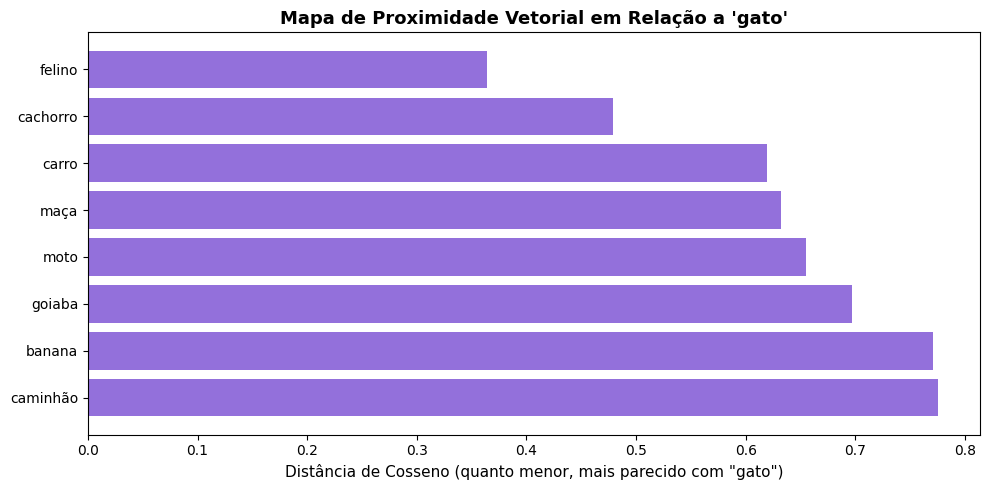

In [12]:
import matplotlib.pyplot as plt

# 1. Calcula e guarda as distâncias em um dicionário chamado 'resultados'
resultados = {}
termo_alvo = "gato"
vetor_alvo = dicionario[termo_alvo]

for palavra, vetor in dicionario.items():
    if palavra != termo_alvo:
        resultados[palavra] = distancia_cosseno(vetor_alvo, vetor)

# 2. Ordena os resultados do mais próximo para o mais distante
resultados_ordenados = sorted(resultados.items(), key=lambda x: x[1])

palavras_plot = [item[0] for item in resultados_ordenados]
distancias_plot = [item[1] for item in resultados_ordenados]

# 3. Criação do gráfico de barras horizontais
plt.figure(figsize=(10, 5))
plt.barh(palavras_plot, distancias_plot, color='mediumpurple')

plt.xlabel('Distância de Cosseno (quanto menor, mais parecido com "gato")', fontsize=11)
plt.title("Mapa de Proximidade Vetorial em Relação a 'gato'", fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Gráfico 2

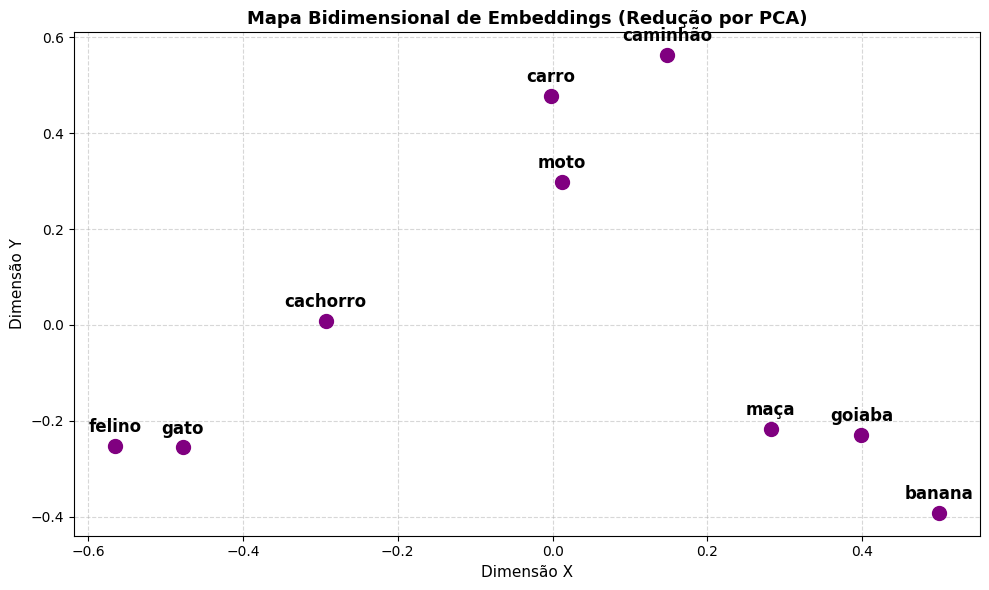

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. Pega as palavras e seus respectivos vetores do dicionário
palavras_lista = list(dicionario.keys())
vetores_matriz = np.array([dicionario[p] for p in palavras_lista])

# 2. Reduz de 1536 dimensões para 2 dimensões (X e Y) usando PCA
pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores_matriz)

x = vetores_2d[:, 0]
y = vetores_2d[:, 1]

# 3. Cria o gráfico de dispersão (pontos na tela)
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='purple', s=100, zorder=5)

# 4. Escreve o nome de cada palavra logo acima do seu respectivo ponto
for i, palavra in enumerate(palavras_lista):
    plt.annotate(
        palavra,
        (x[i], y[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# 5. Estilização do mapa
plt.title("Mapa Bidimensional de Embeddings (Redução por PCA)", fontsize=13, fontweight='bold')
plt.xlabel("Dimensão X", fontsize=11)
plt.ylabel("Dimensão Y", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
Grafico 3

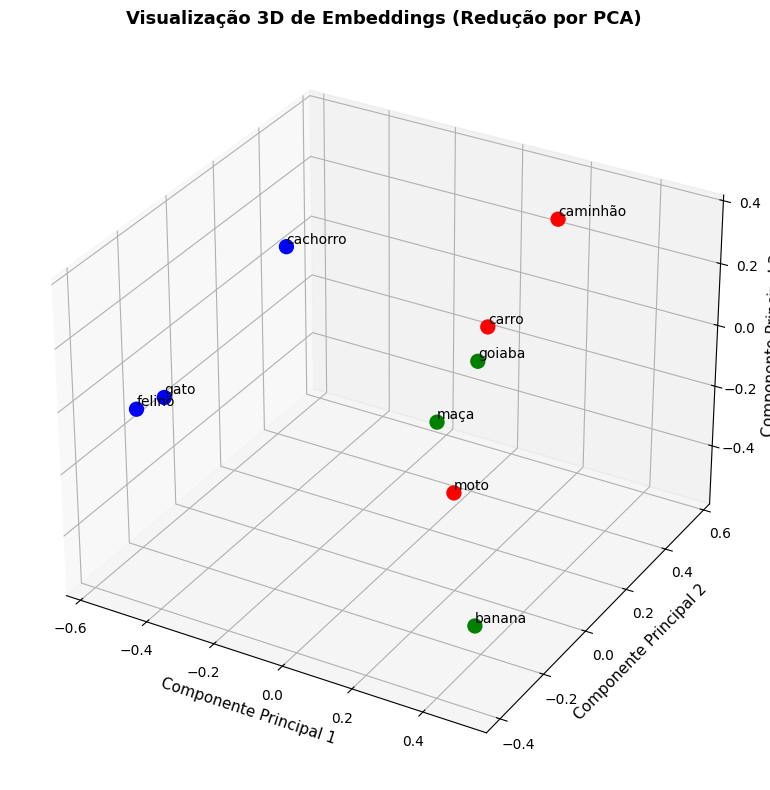

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# Importante: biblioteca para gráficos 3D
from mpl_toolkits.mplot3d import Axes3D

# 1. Prepara os dados (usando o dicionario já existente)
palavras_lista = list(dicionario.keys())
vetores_matriz = np.array([dicionario[p] for p in palavras_lista])

# 2. Redução de Dimensionalidade para 3D (PCA)
# O colega provavelmente fez o mesmo
pca_3d = PCA(n_components=3)
vetores_3d = pca_3d.fit_transform(vetores_matriz)

x_coords = vetores_3d[:, 0]
y_coords = vetores_3d[:, 1]
z_coords = vetores_3d[:, 2]

# 3. Define as cores por grupo (igual ao exemplo do colega)
cores_mapa = []
for palavra in palavras_lista:
    if palavra in ["gato", "felino", "cachorro"]:
        cores_mapa.append('blue') # Animais
    elif palavra in ["carro", "caminhão", "moto"]:
        cores_mapa.append('red') # Veículos
    elif palavra in ["banana", "maça", "goiaba"]:
        cores_mapa.append('green') # Frutas
    else:
        cores_mapa.append('black') # Outros

# 4. Configuração do Gráfico 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plota os pontos coloridos
ax.scatter(x_coords, y_coords, z_coords, c=cores_mapa, s=100, depthshade=False)

# 5. Adiciona os rótulos (nomes das palavras)
for i, palavra in enumerate(palavras_lista):
    ax.text(x_coords[i], y_coords[i], z_coords[i], palavra,
            fontsize=10, ha='left', va='bottom', zorder=10, color='black')

# 6. Estilização dos eixos e título
ax.set_xlabel('Componente Principal 1', fontsize=11)
ax.set_ylabel('Componente Principal 2', fontsize=11)
ax.set_zlabel('Componente Principal 3', fontsize=11)
ax.set_title("Visualização 3D de Embeddings (Redução por PCA)", fontsize=13, fontweight='bold')

# Adiciona grade de fundo e mostra
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

gradi